## Imports & Environment Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Set visual style for PPT-ready charts
sns.set_theme(style="whitegrid", palette="ch:s=-.2,r=.6")

## Data Loading & Feature Engineering

In [7]:
# Load dataset
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Step 1: Create the 'Sleep Quality' Category (Target Variable)
def get_label(score):
    if score >= 8: return 'Good'
    elif score >= 6: return 'Average'
    else: return 'Poor'

df['Target_Quality'] = df['Quality of Sleep'].apply(get_label)

# Step 2: Mapping SRS fields (Simulating Caffeine & Mood for training)
np.random.seed(42) # For consistent results
df['Caffeine_Level'] = np.random.choice([0, 1, 2, 3], size=len(df)) # 0:None, 3:High
df['Mood_Score'] = np.random.choice([0, 1, 2, 3], size=len(df))     # 0:Sad, 3:Happy

print("Dataset ready. Sample rows:")
df.head()

Dataset ready. Sample rows:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Target_Quality,Caffeine_Level,Mood_Score
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,Average,2,0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,Average,3,3
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,Average,0,3
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Poor,2,0
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Poor,2,1


## Data Visualization (Exploratory Data Analysis)

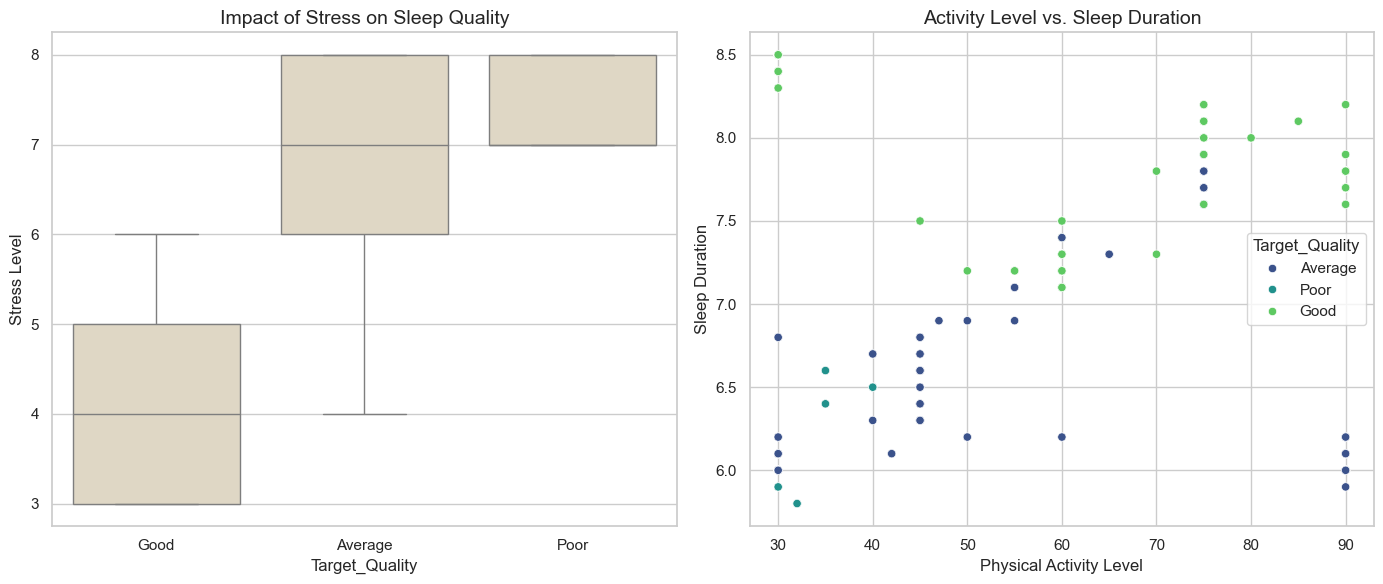

In [8]:
plt.figure(figsize=(14, 6))

# Plot 1: Stress Levels vs Sleep Quality (Boxplot)
plt.subplot(1, 2, 1)
sns.boxplot(x='Target_Quality', y='Stress Level', data=df, order=['Good', 'Average', 'Poor'])
plt.title('Impact of Stress on Sleep Quality', fontsize=14)

# Plot 2: Physical Activity vs Sleep Duration (Scatter)
plt.subplot(1, 2, 2)
sns.scatterplot(x='Physical Activity Level', y='Sleep Duration', hue='Target_Quality', data=df, palette='viridis')
plt.title('Activity Level vs. Sleep Duration', fontsize=14)

plt.tight_layout()
plt.show()

## ML Training with Scaling

In [9]:
# 1. Define Features and Target
features = ['Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Caffeine_Level', 'Mood_Score']
X = df[features]
y = df['Target_Quality']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply Scaling (IMPORTANT for Flask app)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Save Model and Scaler for Flask
joblib.dump(model, 'sleep_predictor_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Training Complete! Accuracy: {accuracy_score(y_test, model.predict(X_test_scaled))*100:.2f}%")

Training Complete! Accuracy: 97.33%


## NLP Logic

In [10]:
def analyze_sleep_diary(text):
    positive_words = ['rested', 'deep', 'calm', 'good', 'refreshed', 'peaceful']
    negative_words = ['tired', 'awake', 'restless', 'anxious', 'noise', 'bad']
    
    score = 0
    words = text.lower().split()
    for word in words:
        if word in positive_words: score += 1
        if word in negative_words: score -= 1
        
    return "Positive Sentiment" if score > 0 else "Negative Sentiment" if score < 0 else "Neutral Sentiment"

# Test prediction
sample_diary = "I felt very refreshed and had a deep sleep."
print(f"Diary Analysis: {analyze_sleep_diary(sample_diary)}")

Diary Analysis: Positive Sentiment
